IMPORT SECTION

In [20]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display
import numpy as np
import h5py
import glob
import json
import imageio
from IPython.display import Image

In [ ]:
import cv2
import glob

libero10_path = "./LIBERO/datasets/libero_10/*.hdf5"

imageio.mimsave(gif_name, frames_resized, fps=20)
    

    
    

    

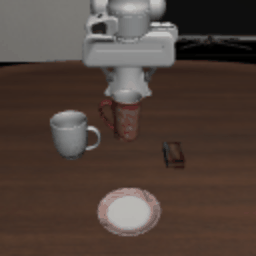

In [110]:
Image(filename=gif_name)

In [ ]:
# 1. Carica il file
file_path = "./processed_data/droid/episode_408.pt" 
sample = torch.load(file_path, weights_only=False)
video = sample['video']  # Shape: [16, 3, 256, 256]
action = sample['actions']

count_lang = 0
for i in range(448):
    sample_i = f"./processed_data/droid/episode_{i}.pt"
    if sample['language_instructions_found'] is True:
        count_lang +=1 

print(f"Samples with language instructions are {count_lang}")





# 2. Converti i Tensori in una lista di immagini PIL
pil_images = []
for i in range(video.shape[0]):
    # Permuta da [C, H, W] a [H, W, C] e converti in numpy uint8
    frame_np = video[i].permute(1, 2, 0).numpy()
    
    # Se i valori sono in range [0, 1] (float), riportali a [0, 255] (uint8)
    if frame_np.max() <= 1.0:
        frame_np = (frame_np * 255).astype(np.uint8)
    else:
        frame_np = frame_np.astype(np.uint8)
        
    pil_images.append(Image.fromarray(frame_np))

# 3. Genera e visualizza la GIF
print(f"Language Instruction founded?: {sample['language_instructions_found']}")
print(f"Language Instruction: {sample['language'][0]}")
print(f"Video in seconds: {sample['video_seconds']}")
gif_data = as_gif(pil_images, path="preview_episode.gif")
display.Image(gif_data)

FileNotFoundError: [Errno 2] No such file or directory: './processed_data/droid/episode_408.pt'